In [6]:
import pandas as pd

df = pd.read_csv("/content/data/water_potability.csv")

# Fill missing values with median (better than mean for skewed data)
df['ph'] = df['ph'].fillna(df['ph'].median())
df['Sulfate'] = df['Sulfate'].fillna(df['Sulfate'].median())
df['Trihalomethanes'] = df['Trihalomethanes'].fillna(df['Trihalomethanes'].median())

print(df.isnull().sum())  # should show all zeros now

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


In [4]:
print(df.duplicated().sum())  # if > 0, run:
df = df.drop_duplicates()

0


In [5]:
df.to_csv("data/water_potability_clean.csv", index=False)
print("Saved!")

Saved!


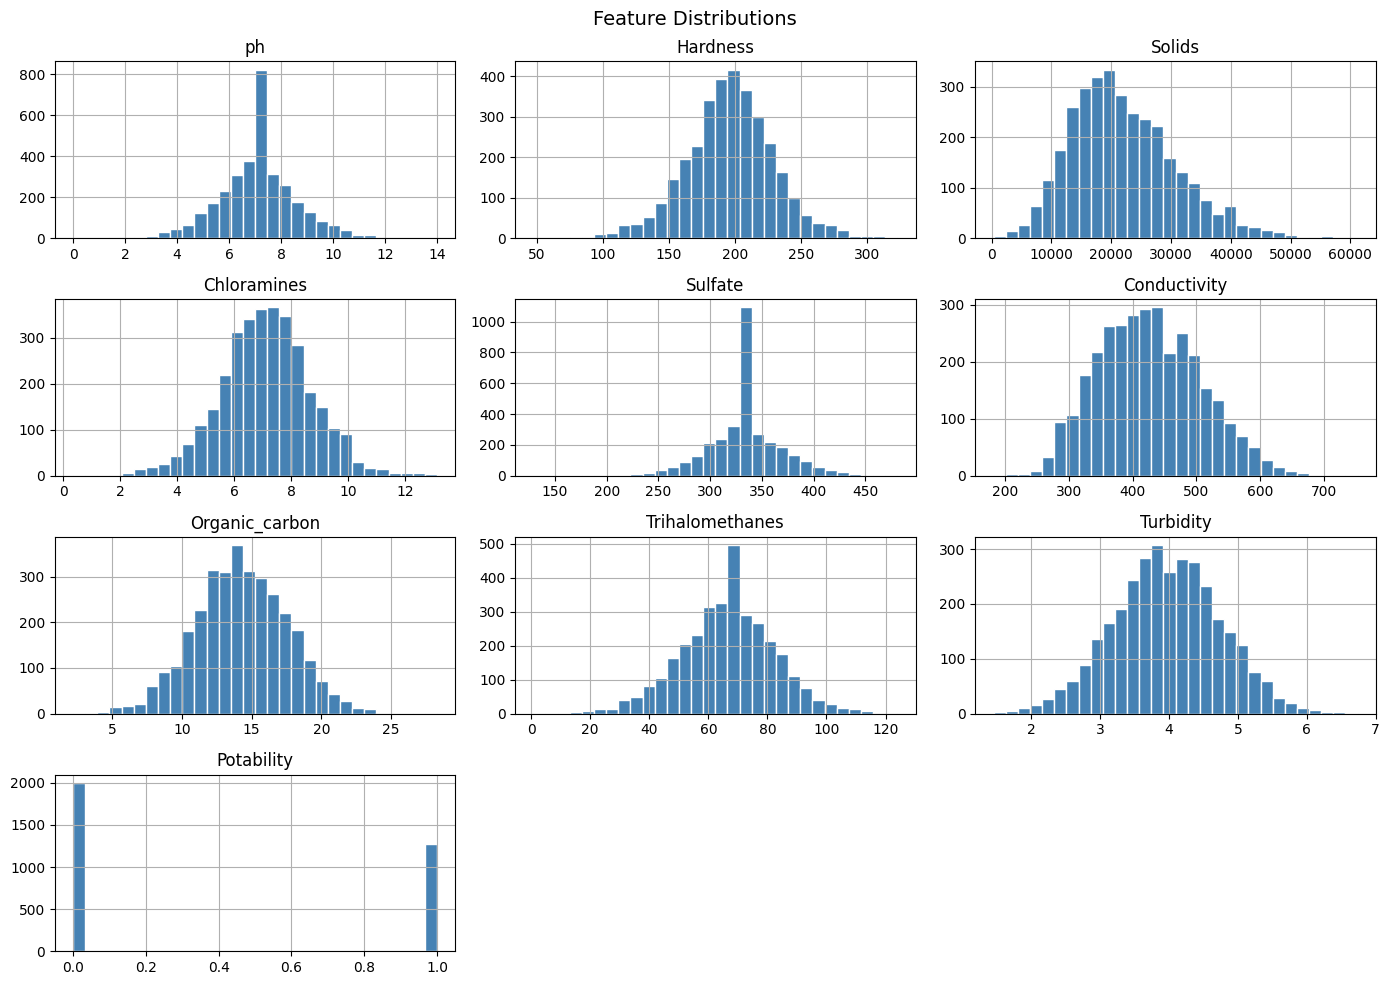

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/water_potability_clean.csv")

# Plot distribution of every feature
df.hist(figsize=(14, 10), bins=30, color='steelblue', edgecolor='white')
plt.suptitle("Feature Distributions", fontsize=14)
plt.tight_layout()
plt.savefig("visuals/feature_distributions.png")
plt.show()

Potability
0    1998
1    1278
Name: count, dtype: int64


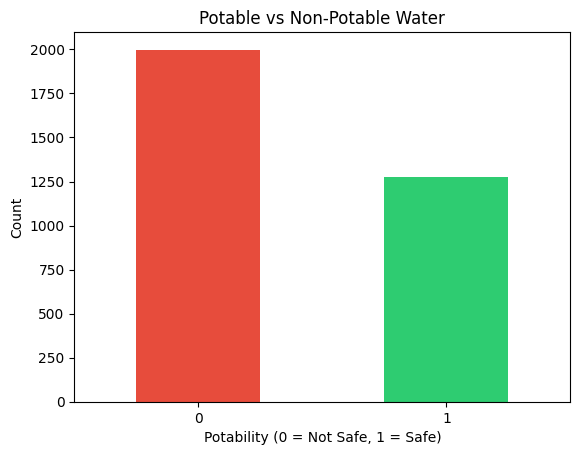

In [8]:
print(df['Potability'].value_counts())

df['Potability'].value_counts().plot(kind='bar', color=['#E74C3C','#2ECC71'])
plt.title("Potable vs Non-Potable Water")
plt.xlabel("Potability (0 = Not Safe, 1 = Safe)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.savefig("visuals/class_balance.png")
plt.show()

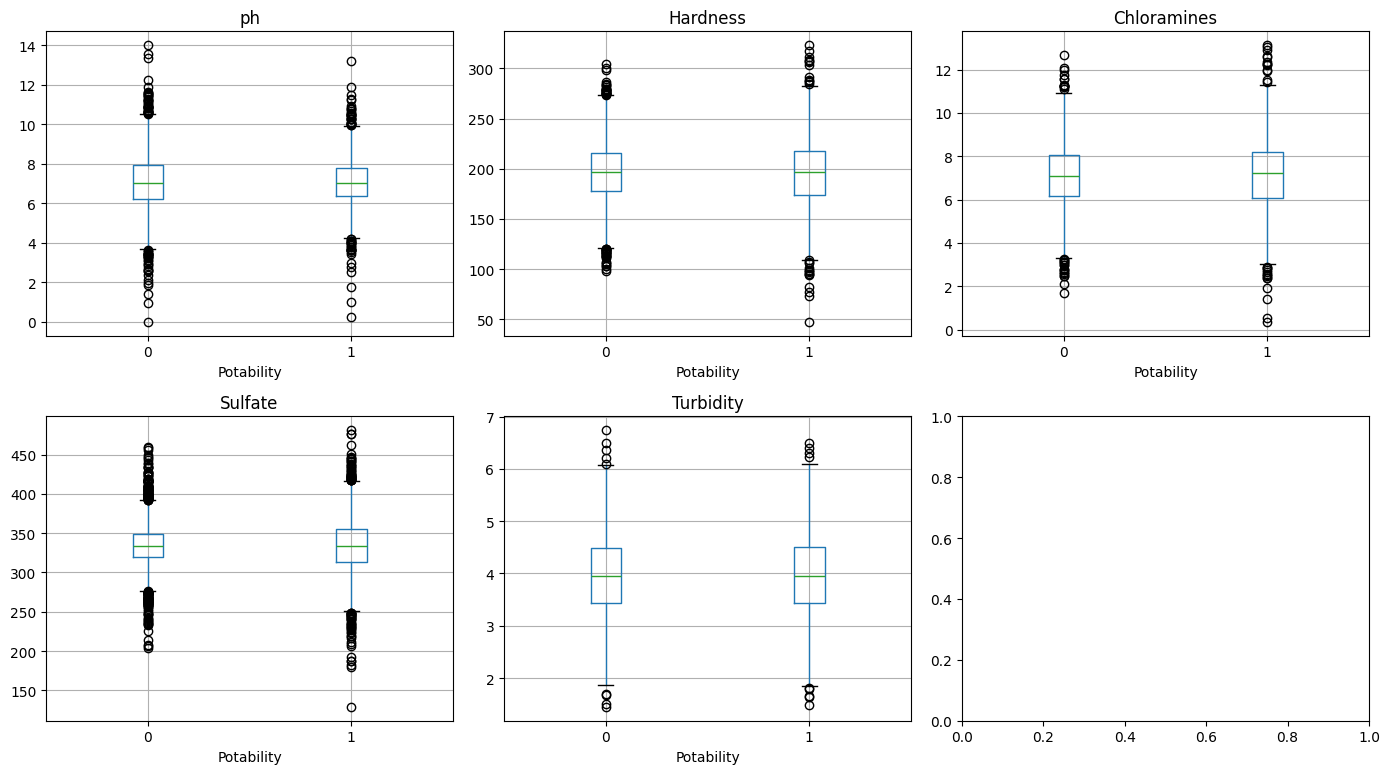

In [9]:
# Boxplots: does pH differ between safe and unsafe water?
features = ['ph', 'Hardness', 'Chloramines', 'Sulfate', 'Turbidity']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    df.boxplot(column=col, by='Potability', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("Potability")

plt.suptitle("")
plt.tight_layout()
plt.savefig("visuals/boxplots.png")
plt.show()

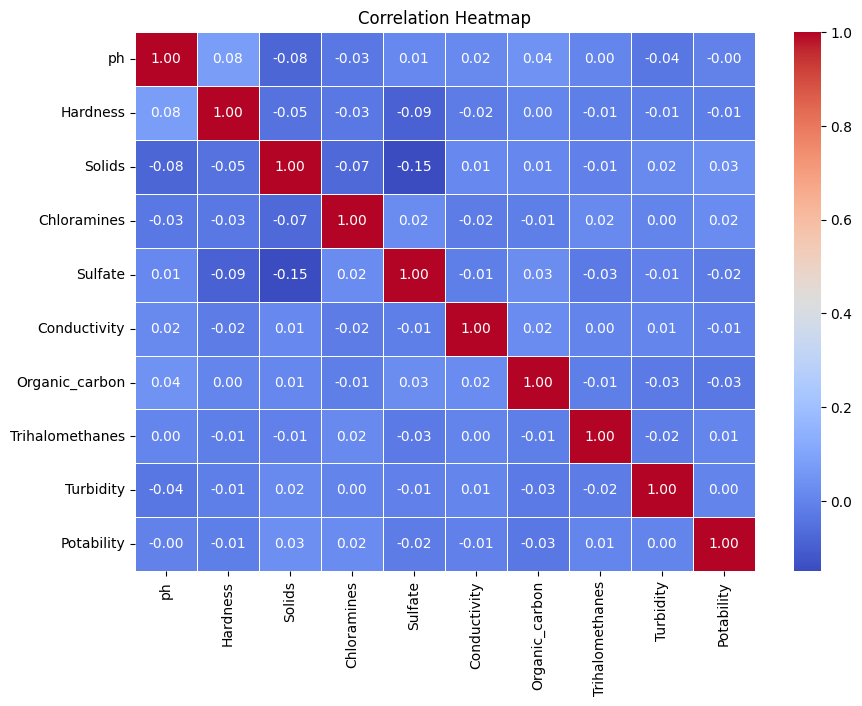

In [10]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.savefig("visuals/correlation_heatmap.png")
plt.show()